In [2]:
import pandas as pd
import numpy as np
import os 
import matplotlib.pyplot as plt

In [3]:
# List of file paths
file_paths = [
    "C:/Users/LHansen/OneDrive - Land Information New Zealand/2025/Python/Scripts/PositioNZ_converted_coordinates.csv",
    "C:/Users/LHansen/OneDrive - Land Information New Zealand/2025/Python/Scripts/Synergy_converted_coordinates.csv",
    "C:/Users/LHansen/OneDrive - Land Information New Zealand/2025/Python/Scripts/Trimble_converted_coordinates.csv",
    "C:/Users/LHansen/OneDrive - Land Information New Zealand/2025/Python/Scripts/Elliot_Sinclair_converted_coordinates.csv",
    "C:/Users/LHansen/OneDrive - Land Information New Zealand/2025/Python/Scripts/Global_Survey_converted_coordinates.csv",
    "C:/Users/LHansen/OneDrive - Land Information New Zealand/2025/Python/Scripts/Position_Partners_converted_coordinates.csv",
    "C:/Users/LHansen/OneDrive - Land Information New Zealand/2025/Python/Scripts/Survey_Hire_converted_coordinates.csv"
]

In [4]:
# Function to calculate RMS position
def calculate_rms_position(df):
    return (
        np.sqrt(np.mean(df['nztm2000_lon']**2)),
        np.sqrt(np.mean(df['nztm2000_lat']**2)),
        np.sqrt(np.mean(df['nzvd2016_elev']**2))
    )

In [5]:
# Function to compute drift stats
def compute_drift_stats(df):
    rms_lon, rms_lat, rms_elev = calculate_rms_position(df)
    df['horizontal_drift'] = np.sqrt((df['nztm2000_lon'] - rms_lon)**2 + (df['nztm2000_lat'] - rms_lat)**2)
    df['3d_drift'] = np.sqrt(df['horizontal_drift']**2 + (df['nzvd2016_elev'] - rms_elev)**2)
    df['3d_drift_mm'] = df['3d_drift'] * 1000

    mean_drift = df['3d_drift_mm'].mean()
    std_drift = df['3d_drift_mm'].std()
    thresholds = [0.01, 0.02, 0.05]
    percentages = [(df['3d_drift'] <= t).mean() * 100 for t in thresholds]

    return mean_drift, std_drift, percentages




In [6]:
# Collect results
results = []

for file_path in file_paths:
    df = pd.read_csv(file_path)
    df['date'] = pd.to_datetime(df['date'])

    for station in df['station'].unique():
        station_df = df[df['station'] == station].copy()
        mean_drift, std_drift, percentages = compute_drift_stats(station_df)
        results.append([station, mean_drift, std_drift] + percentages)


In [7]:
# Create summary table
columns = [
    'Station', 'Mean 3D Drift (mm)', 'Std 3D Drift (mm)',
    'Within 1 cm (%)', 'Within 2 cm (%)', 'Within 5 cm (%)'
]
summary_df = pd.DataFrame(results, columns=columns)

# Display the table
print(summary_df.to_string(index=False))


Station  Mean 3D Drift (mm)  Std 3D Drift (mm)  Within 1 cm (%)  Within 2 cm (%)  Within 5 cm (%)
   AUCK            4.872024           2.184584        98.888889       100.000000       100.000000
   VGMT            4.843149           2.252084        98.888889       100.000000       100.000000
   GISB            4.403239           2.075808        97.777778       100.000000       100.000000
   WGTN            5.618839           2.515100        95.555556       100.000000       100.000000
   DUND            5.253121           2.447734        96.666667       100.000000       100.000000
   PYGR            4.999886           2.417668        97.752809       100.000000       100.000000
   MAVL            6.066880           3.163337        86.666667       100.000000       100.000000
   WHKT            4.748334           2.394901        96.666667       100.000000       100.000000
   DNVK            5.026942           2.714020        96.666667       100.000000       100.000000
   NPLY            5

In [8]:
# Define the RSM value calcuations for each of the inputs from the CSV files above
def calculate_rms(df):
    return (
        np.sqrt(np.mean(df['nztm2000_lon']**2)),
        np.sqrt(np.mean(df['nztm2000_lat']**2)),
        np.sqrt(np.mean(df['nzvd2016_elev']**2))
    )

# Define the calcualted 3D drift from the calcaulted RMS value caclcualted above
def compute_3d_drift(df):
    rms_lon, rms_lat, rms_elev = calculate_rms(df)
    df['horizontal_drift'] = np.sqrt((df['nztm2000_lon'] - rms_lon)**2 + (df['nztm2000_lat'] - rms_lat)**2)
    df['3d_drift'] = np.sqrt(df['horizontal_drift']**2 + (df['nzvd2016_elev'] - rms_elev)**2)
    return df['3d_drift'] * 1000  # convert to mm





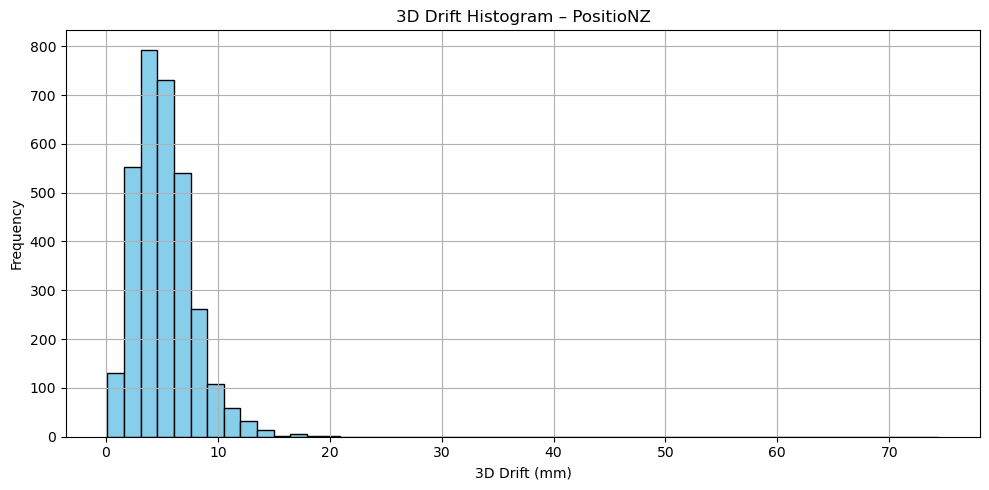

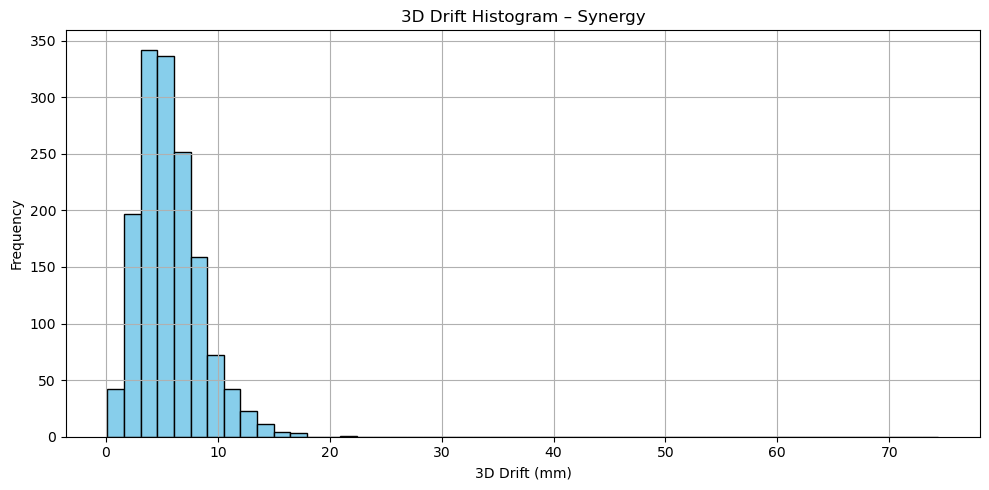

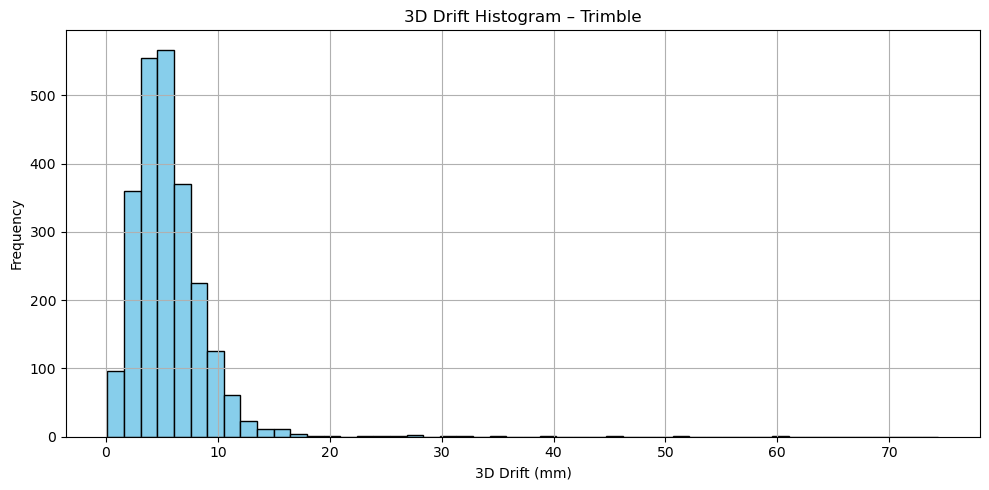

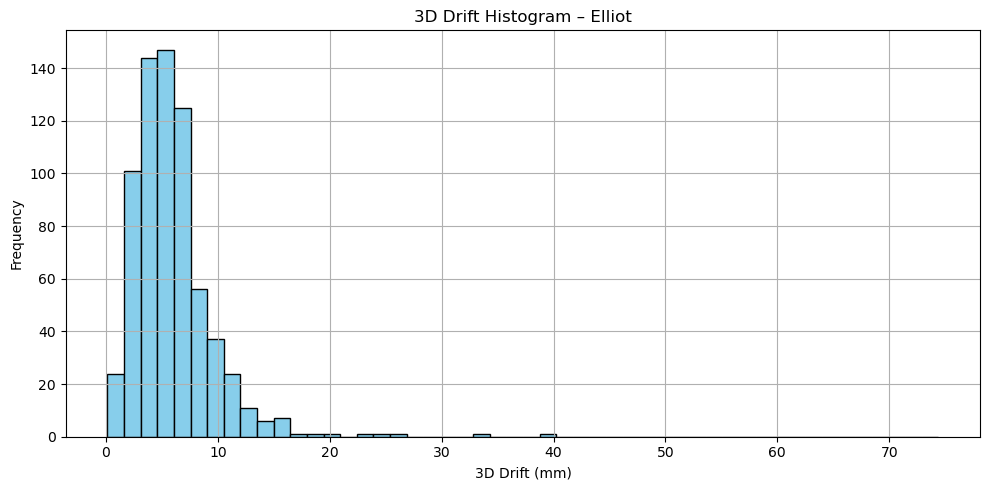

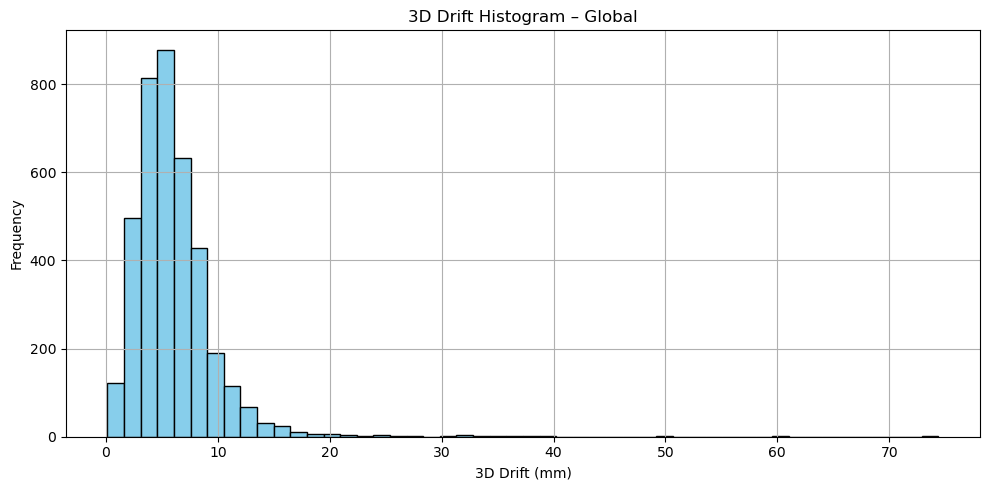

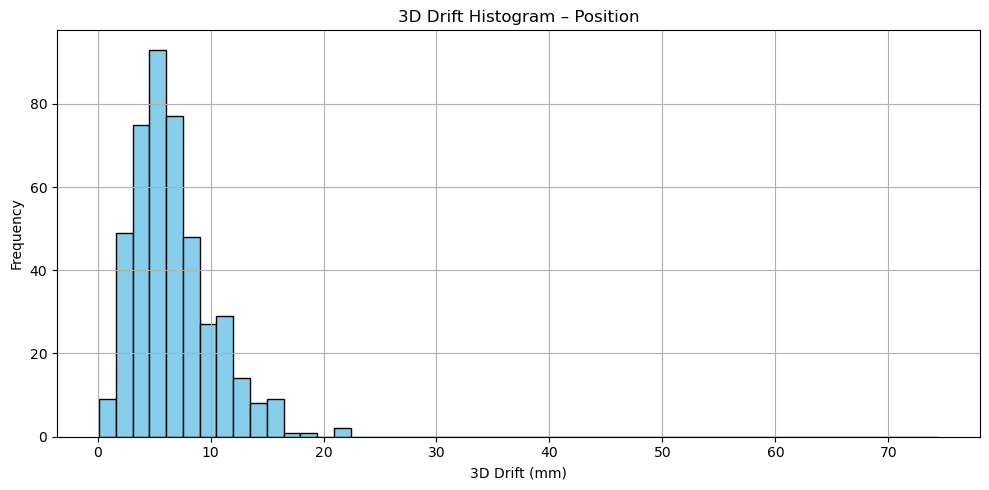

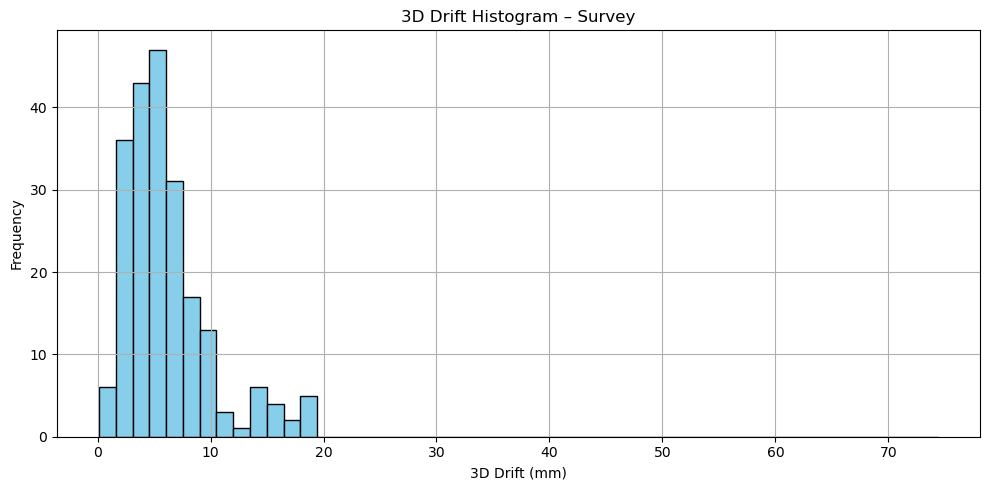

In [9]:
# First pass: find global min and max of all drift values, apply this so that all of the x axes are the same scale
global_min = float('inf')
global_max = float('-inf')
drift_data_per_file = {}

for path in file_paths:
    df = pd.read_csv(path)
    df['date'] = pd.to_datetime(df['date'])

    all_drift_mm = pd.Series(dtype=float)
    for station in df['station'].unique():
        station_df = df[df['station'] == station].copy()
        all_drift_mm = pd.concat([all_drift_mm, compute_3d_drift(station_df)])

    drift_data_per_file[path] = all_drift_mm
    if not all_drift_mm.empty:
        global_min = min(global_min, all_drift_mm.min())
        global_max = max(global_max, all_drift_mm.max())

# Second pass: plot histograms with consistent x axis range
for path, all_drift_mm in drift_data_per_file.items():
    label = os.path.basename(path).split('_')[0]

    plt.figure(figsize=(10, 5))
    plt.hist(all_drift_mm, bins=50, range=(global_min, global_max), color='skyblue', edgecolor='black')
    plt.title(f'3D Drift Histogram – {label}')
    plt.xlabel('3D Drift (mm)')
    plt.ylabel('Frequency')
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [10]:
# Print the statistics for the plots above
for path, all_drift_mm in drift_data_per_file.items():
    label = os.path.basename(path).split('_')[0]

    print(f"Statistics for {label}:")
    print(f"  Mean: {all_drift_mm.mean():.3f} mm")
    print(f"  Median: {all_drift_mm.median():.3f} mm")
    print(f"  Std Dev: {all_drift_mm.std():.3f} mm")
    print(f"  Min: {all_drift_mm.min():.3f} mm")
    print(f"  Max: {all_drift_mm.max():.3f} mm\n")


Statistics for PositioNZ:
  Mean: 5.162 mm
  Median: 4.836 mm
  Std Dev: 2.533 mm
  Min: 0.215 mm
  Max: 20.675 mm

Statistics for Synergy:
  Mean: 5.671 mm
  Median: 5.312 mm
  Std Dev: 2.713 mm
  Min: 0.313 mm
  Max: 22.042 mm

Statistics for Trimble:
  Mean: 5.600 mm
  Median: 5.084 mm
  Std Dev: 3.514 mm
  Min: 0.126 mm
  Max: 60.592 mm

Statistics for Elliot:
  Mean: 5.913 mm
  Median: 5.331 mm
  Std Dev: 3.628 mm
  Min: 0.460 mm
  Max: 39.789 mm

Statistics for Global:
  Mean: 6.034 mm
  Median: 5.383 mm
  Std Dev: 3.976 mm
  Min: 0.231 mm
  Max: 74.396 mm

Statistics for Position:
  Mean: 6.664 mm
  Median: 6.015 mm
  Std Dev: 3.466 mm
  Min: 0.643 mm
  Max: 21.445 mm

Statistics for Survey:
  Mean: 6.040 mm
  Median: 5.059 mm
  Std Dev: 3.766 mm
  Min: 0.308 mm
  Max: 18.918 mm



In [11]:
# Define the outlier filter using the IRQ
def remove_outliers_iqr(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return series[(series >= lower) & (series <= upper)], lower, upper

# Loop the filter over each of the datasets 
for path in file_paths:
    try:
        df = pd.read_csv(path)
        df['date'] = pd.to_datetime(df['date'])

        all_drift_mm = pd.Series(dtype=float)
        drift_info = []

        for station in df['station'].unique():
            station_df = df[df['station'] == station].copy()
            station_df['3d_drift'] = compute_3d_drift(station_df)
            drift_info.append(station_df[['station', 'date', '3d_drift']])
            all_drift_mm = pd.concat([all_drift_mm, station_df['3d_drift']])

        drift_df = pd.concat(drift_info)
        filtered_drift, lower, upper = remove_outliers_iqr(drift_df['3d_drift'])

        label = os.path.basename(path).split('_')[0]
        print(f"\nStatistics for {label} (after IQR filtering):")
        print(f"  Mean: {filtered_drift.mean():.3f} mm")
        print(f"  Median: {filtered_drift.median():.3f} mm")
        print(f"  Std Dev: {filtered_drift.std():.3f} mm")
        print(f"  Min: {filtered_drift.min():.3f} mm")
        print(f"  Max: {filtered_drift.max():.3f} mm")
        print("=" * 80)

        # Print outliers
        outliers = drift_df[(drift_df['3d_drift'] < lower) | (drift_df['3d_drift'] > upper)]
        print(f"Outliers removed for {label}:")
        if outliers.empty:
            print("  None")
        else:
            for _, row in outliers.iterrows():
                print(f"  Station: {row['station']}, Date: {row['date'].date()}, 3D Drift: {row['3d_drift']:.3f} mm")
        print("=" * 80)

    except FileNotFoundError:
        print(f"File not found: {path}")
    except Exception as e:
        print(f"Error processing {path}: {e}")



Statistics for PositioNZ (after IQR filtering):
  Mean: 4.956 mm
  Median: 4.759 mm
  Std Dev: 2.183 mm
  Min: 0.215 mm
  Max: 11.379 mm
Outliers removed for PositioNZ:
  Station: AUCK, Date: 2025-01-25, 3D Drift: 13.637 mm
  Station: GISB, Date: 2025-03-17, 3D Drift: 12.721 mm
  Station: WGTN, Date: 2025-02-18, 3D Drift: 12.544 mm
  Station: WGTN, Date: 2025-03-17, 3D Drift: 12.025 mm
  Station: WGTN, Date: 2025-03-22, 3D Drift: 14.705 mm
  Station: DUND, Date: 2025-01-16, 3D Drift: 12.418 mm
  Station: DUND, Date: 2025-03-30, 3D Drift: 11.661 mm
  Station: PYGR, Date: 2025-03-09, 3D Drift: 11.728 mm
  Station: MAVL, Date: 2025-01-10, 3D Drift: 11.514 mm
  Station: MAVL, Date: 2025-01-11, 3D Drift: 11.713 mm
  Station: MAVL, Date: 2025-01-16, 3D Drift: 11.994 mm
  Station: MAVL, Date: 2025-02-08, 3D Drift: 14.393 mm
  Station: MAVL, Date: 2025-03-01, 3D Drift: 12.751 mm
  Station: MAVL, Date: 2025-03-02, 3D Drift: 12.714 mm
  Station: MAVL, Date: 2025-03-26, 3D Drift: 15.058 mm
  Sta

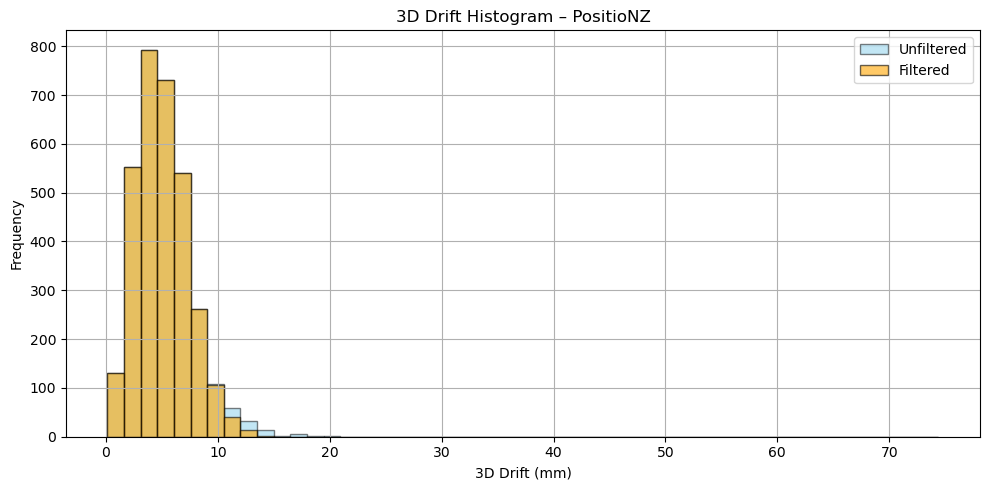

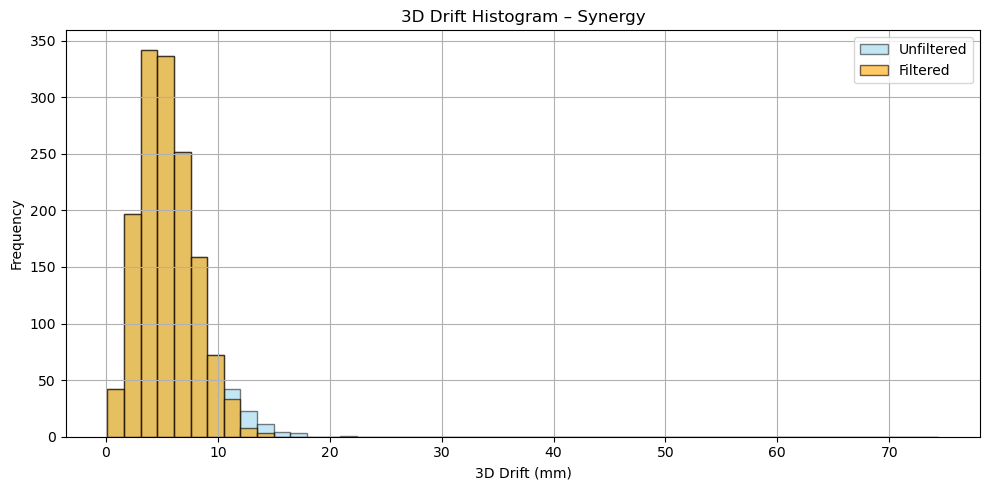

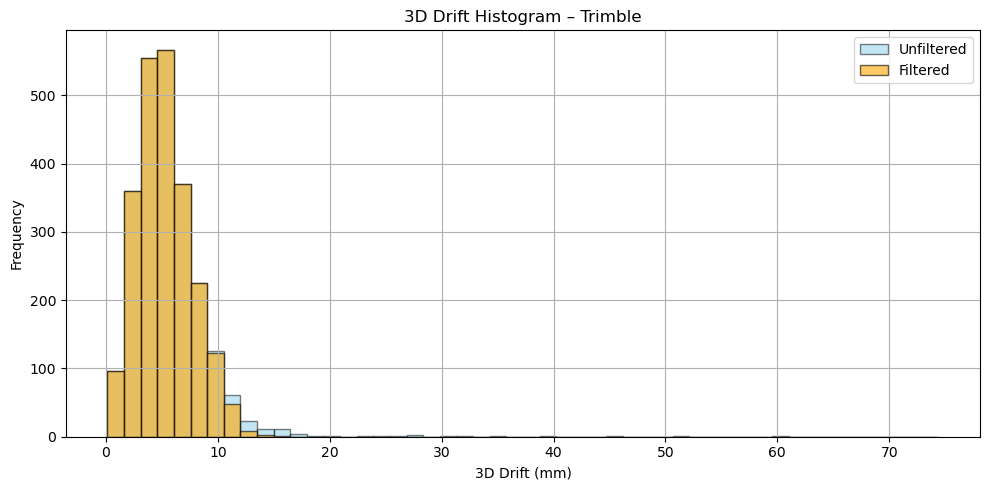

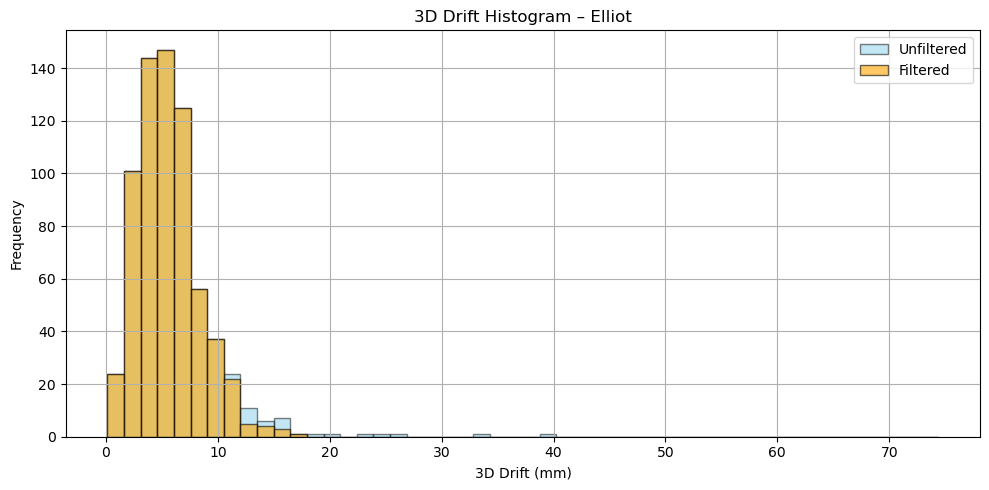

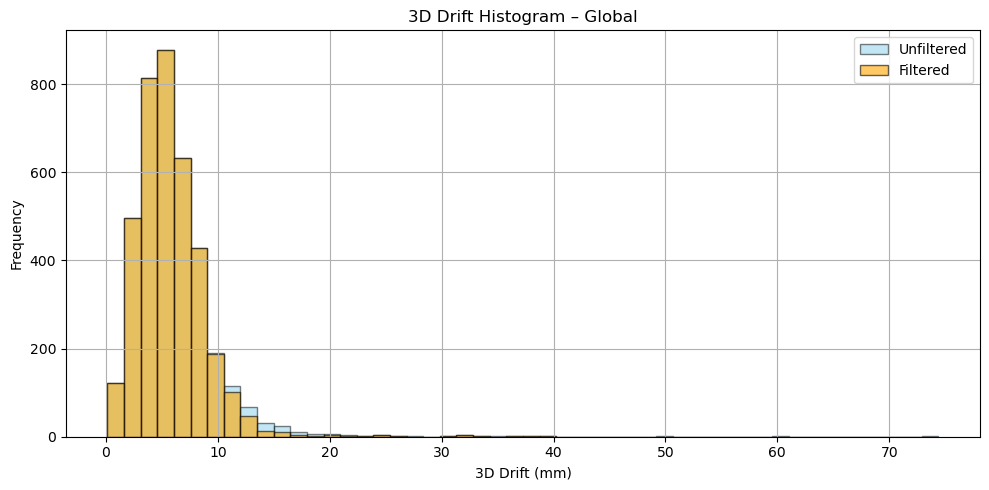

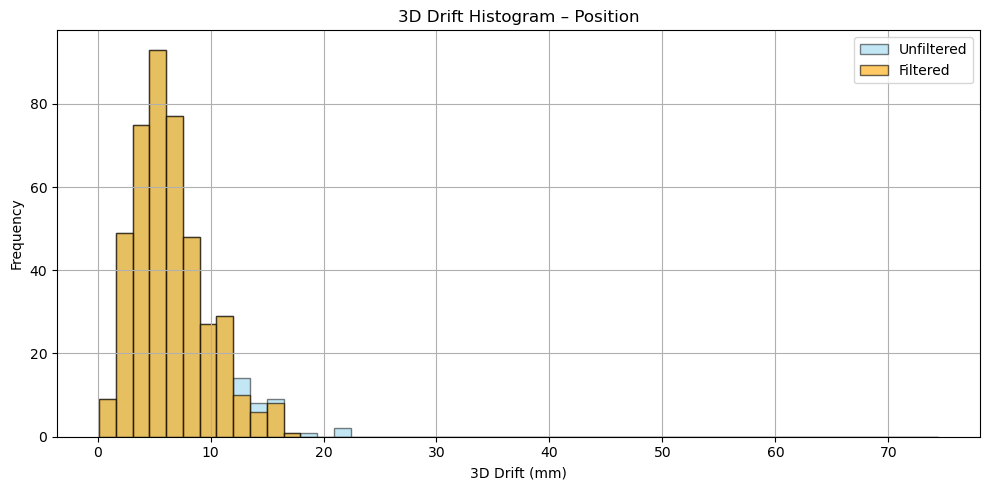

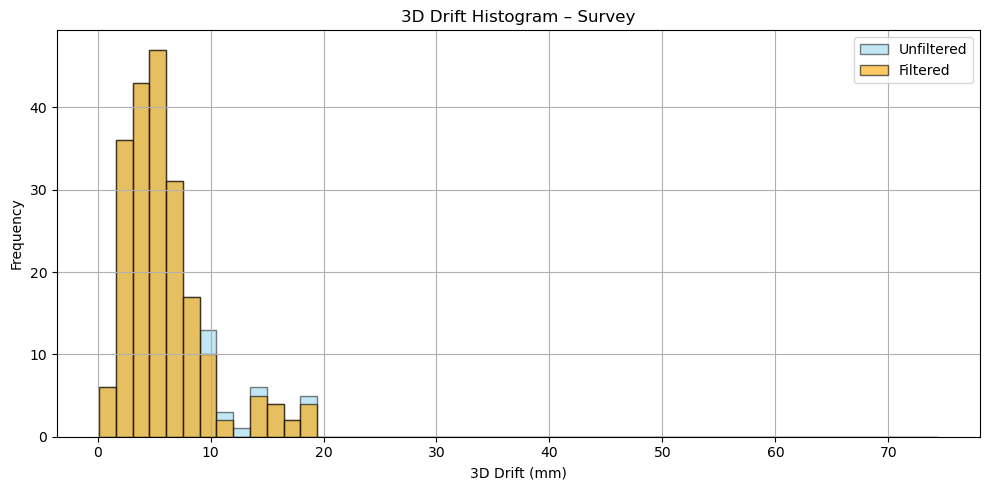

In [12]:

for path in file_paths:
    label = os.path.basename(path).split('_')[0]
    df = pd.read_csv(path)
    df['date'] = pd.to_datetime(df['date'])

    all_drift_mm = pd.Series(dtype=float)
    filtered_drift_mm = pd.Series(dtype=float)

    for station in df['station'].unique():
        station_df = df[df['station'] == station].copy()
        station_df['3d_drift'] = compute_3d_drift(station_df)
        all_drift_mm = pd.concat([all_drift_mm, station_df['3d_drift']])
        filtered, _, _ = remove_outliers_iqr(station_df['3d_drift'])
        filtered_drift_mm = pd.concat([filtered_drift_mm, filtered])

    plt.figure(figsize=(10, 5))
    plt.hist(all_drift_mm, bins=50, range=(global_min, global_max), color='skyblue', edgecolor='black', alpha=0.5, label='Unfiltered')
    plt.hist(filtered_drift_mm, bins=50, range=(global_min, global_max), color='orange', edgecolor='black', alpha=0.6, label='Filtered')
    plt.title(f'3D Drift Histogram – {label}')
    plt.xlabel('3D Drift (mm)')
    plt.ylabel('Frequency')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [53]:
# Load PositioNZ benchmark
benchmark_df = pd.read_csv(file_paths["PositioNZ"])
benchmark_df['date'] = pd.to_datetime(benchmark_df['date'])

# Function to compute RMS position for a station
def calculate_rms_position(df):
    rms_lon = np.sqrt(np.mean(df['nztm2000_lon']**2))
    rms_lat = np.sqrt(np.mean(df['nztm2000_lat']**2))
    rms_elev = np.sqrt(np.mean(df['nzvd2016_elev']**2))
    return rms_lon, rms_lat, rms_elev

# Function to compute drift stats with IQR filtering
def compute_drift_stats(df, rms_lon, rms_lat, rms_elev):
    df['horizontal_drift'] = np.sqrt((df['nztm2000_lon'] - rms_lon)**2 + (df['nztm2000_lat'] - rms_lat)**2)
    df['3d_drift'] = np.sqrt(df['horizontal_drift']**2 + (df['nzvd2016_elev'] - rms_elev)**2)
    df['3d_drift_mm'] = df['3d_drift'] * 1000

    # Apply IQR filter
    Q1 = df['3d_drift_mm'].quantile(0.25)
    Q3 = df['3d_drift_mm'].quantile(0.75)
    IQR = Q3 - Q1
    filtered_df = df[(df['3d_drift_mm'] >= Q1 - 1.5 * IQR) & (df['3d_drift_mm'] <= Q3 + 1.5 * IQR)]

    mean_drift = filtered_df['3d_drift_mm'].mean()
    std_drift = filtered_df['3d_drift_mm'].std()

    return mean_drift, std_drift

# Compute drift stats per station
station_mean_drifts = []

for station in benchmark_df['station'].unique():
    station_df = benchmark_df[benchmark_df['station'] == station].copy()
    rms_lon, rms_lat, rms_elev = calculate_rms_position(station_df)
    mean_drift, _ = compute_drift_stats(station_df, rms_lon, rms_lat, rms_elev)
    station_mean_drifts.append(mean_drift)

# Compute benchmark stats from station-level means
benchmark_mean_drift = np.mean(station_mean_drifts)
benchmark_std_drift = np.std(station_mean_drifts)

# Print benchmark stats
print("Benchmark (PositioNZ) Statistics (based on station-level means):")
print(f"Mean 3D Drift (mm): {benchmark_mean_drift:.2f}")
print(f"Std 3D Drift (mm): {benchmark_std_drift:.2f}")
print()



Benchmark (PositioNZ) Statistics (based on station-level means):
Mean 3D Drift (mm): 5.00
Std 3D Drift (mm): 0.50



In [70]:
# Analyse all other networks
results = []

for network, path in file_paths.items():
    if network == "PositioNZ":
        continue

    df = pd.read_csv(path)
    df['date'] = pd.to_datetime(df['date'])

    for station in df['station'].unique():
        station_df = df[df['station'] == station].copy()
        
        # Compute station-specific RMS
        rms_lon, rms_lat, rms_elev = calculate_rms_position(station_df)
        
        # Compute drift relative to its own RMS
        mean_drift, std_drift = compute_drift_stats(station_df, rms_lon, rms_lat, rms_elev)
        
        # Compare to benchmark
        deviation_from_benchmark = (mean_drift - benchmark_mean_drift) / benchmark_std_drift
        
        if deviation_from_benchmark >= 2:
            results.append([network, station, mean_drift, std_drift, deviation_from_benchmark])

# Create summary table
columns = ['Network', 'Station', 'Mean 3D Drift (mm)', 'Std 3D Drift (mm)', 'Deviation from Benchmark (std)']
summary_df = pd.DataFrame(results, columns=columns)

# Display the table
print(summary_df.to_string(index=False))


          Network Station  Mean 3D Drift (mm)  Std 3D Drift (mm)  Deviation from Benchmark (std)
          Synergy    SYET            6.059331           3.048264                        2.114875
          Synergy    SYQN            6.043307           2.342434                        2.082918
          Trimble    VAK2            7.185851           3.033679                        4.361546
          Trimble    VPN2            6.033716           2.584353                        2.063790
          Trimble    VZQN            6.163180           2.360143                        2.321986
          Trimble    VWAN            6.409267           2.985095                        2.812770
          Trimble    VTEA            6.791081           3.174009                        3.574238
  Elliot_Sinclair    ESPM            7.460738           3.805823                        4.909766
  Elliot_Sinclair    ESQT            6.412932           2.788266                        2.820078
    Global_Survey    GSPM     

In [76]:
results = []
total_stations = 0
excluded_stations = 0

for network, path in file_paths.items():
    if network == "PositioNZ":
        continue

    df = pd.read_csv(path)
    df['date'] = pd.to_datetime(df['date'])

    for station in df['station'].unique():
        total_stations += 1
        station_df = df[df['station'] == station].copy()
        
        # Compute station-specific RMS
        rms_lon, rms_lat, rms_elev = calculate_rms_position(station_df)
        
        # Compute drift relative to its own RMS
        mean_drift, std_drift = compute_drift_stats(station_df, rms_lon, rms_lat, rms_elev)
        
        # Compare to benchmark
        deviation_from_benchmark = (mean_drift - benchmark_mean_drift) / benchmark_std_drift
        
        if deviation_from_benchmark >= 2:
            excluded_stations += 1
            results.append([network, station, mean_drift, std_drift, deviation_from_benchmark])

# Print exclusion statistics
print(f"Total stations analysed: {total_stations}")
print(f"Number of stations excluded: {excluded_stations}")
print(f"Percentage of stations excluded: {excluded_stations / total_stations * 100:.2f}%")


Total stations analysed: 108
Number of stations excluded: 23
Percentage of stations excluded: 21.30%


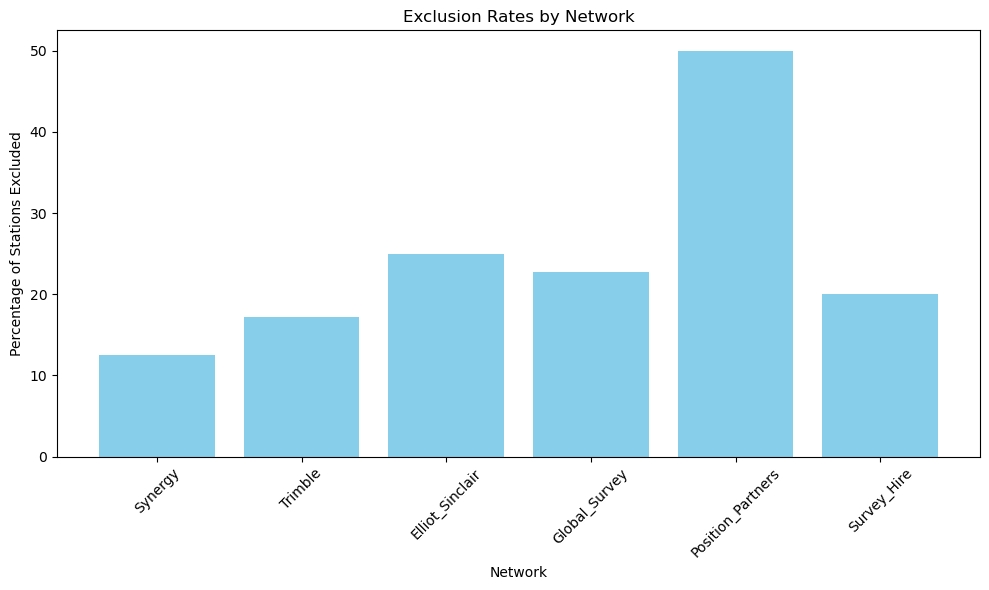

In [79]:
# Count total and excluded stations per network
from collections import defaultdict

network_station_counts = defaultdict(int)
network_excluded_counts = defaultdict(int)

for row in results:
    network = row[0]
    network_excluded_counts[network] += 1

# Count total stations per network from the original data
for network, path in file_paths.items():
    if network == "PositioNZ":
        continue
    df = pd.read_csv(path)
    for station in df['station'].unique():
        network_station_counts[network] += 1

# Compute exclusion rates
exclusion_rates = {
    network: (network_excluded_counts[network] / network_station_counts[network]) * 100
    for network in network_station_counts
}

# Plot the bar chart
plt.figure(figsize=(10, 6))
plt.bar(exclusion_rates.keys(), exclusion_rates.values(), color='skyblue')
plt.xlabel('Network')
plt.ylabel('Percentage of Stations Excluded')
plt.title('Exclusion Rates by Network')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


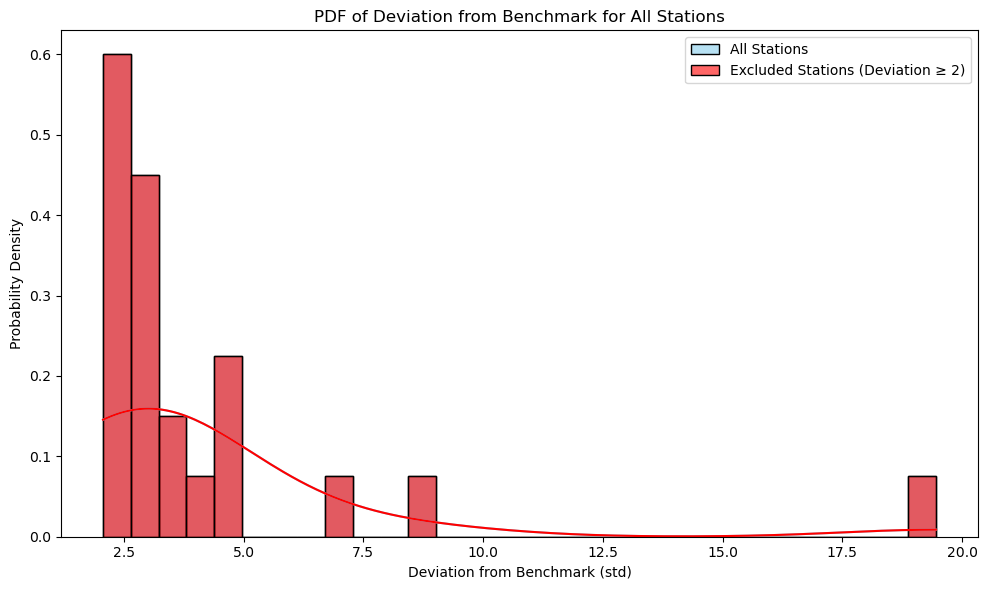

In [81]:
import matplotlib.pyplot as plt
import seaborn as sns

# Extract deviations from results
deviations = [row[4] for row in results]

# Create histogram bins
bins = 30

# Plot the PDF with KDE
plt.figure(figsize=(10, 6))
sns.histplot(deviations, bins=bins, kde=True, color='skyblue', label='All Stations', stat='density', alpha=0.6)

# Highlight excluded stations (deviation >= 2)
excluded_deviations = [dev for dev in deviations if dev >= 2]
sns.histplot(excluded_deviations, bins=bins, kde=True, color='red', label='Excluded Stations (Deviation ≥ 2)', stat='density', alpha=0.6)

# Add labels and title
plt.xlabel('Deviation from Benchmark (std)')
plt.ylabel('Probability Density')
plt.title('PDF of Deviation from Benchmark for All Stations')
plt.legend()
plt.tight_layout()
plt.show()
